**Ten kod jest praktycznie taki sam jak przy metodach do klasteringu więc wszystkiego nie komentuję. Komentuje tylko fragtment kodu gdzie redukuje wymiarowość.**

In [ ]:
from pathlib import Path
import pandas as pd
from sklearn.cluster import KMeans, DBSCAN
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
import seaborn as sns
from sklearn.model_selection import KFold
from sklearn.linear_model import SGDClassifier
from sklearn.decomposition import PCA

In [ ]:
def load_samsung_data():
      filename_train = "samsung_train.txt"
      filename_test = "samsung_test.txt"
      filename_labels = "samsung_train_labels.txt"
      Path("data/samsungData").mkdir(parents=True, exist_ok=True)
      return pd.read_csv(Path("data/samsungData") / filename_train, delim_whitespace=True, header=None), \
      pd.read_csv(Path("data/samsungData") / filename_test, delim_whitespace=True, header=None), \
      pd.read_csv(Path("data/samsungData") / filename_labels, delim_whitespace=True, header=None)

train_data, test_data, y = load_samsung_data()

/tmp/ipython-input-6-3093572585.py:6: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  return pd.read_csv(Path("data/samsungData") / filename_train, delim_whitespace=True, header=None), \
/tmp/ipython-input-6-3093572585.py:7: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  pd.read_csv(Path("data/samsungData") / filename_test, delim_whitespace=True, header=None), \
/tmp/ipython-input-6-3093572585.py:8: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  pd.read_csv(Path("data/samsungData") / filename_labels, delim_whitespace=True, header=None)


In [ ]:
print("Liczba wymiarów (cech):", train_data.shape[1])

Liczba wymiarów (cech): 561


In [ ]:
scaler = StandardScaler()
X = scaler.fit_transform(train_data)
Y_test = scaler.transform(test_data)

In [ ]:
# tutaj redukuje wymiary z 561 cech do 100
pca = PCA(n_components = 100)
X_pca = pca.fit_transform(X)
Y_test_pca = pca.transform(Y_test)

In [ ]:
# wykresy do wyznaczania granic decyzyjnych
def plot_data(X):
    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)

def plot_centroids(centroids, weights=None, circle_color='w', cross_color='k'):
    if weights is not None:
        centroids = centroids[weights > weights.max() / 10]
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='o', s=30, linewidths=8,
                color=circle_color, zorder=10, alpha=0.9)
    plt.scatter(centroids[:, 0], centroids[:, 1],
                marker='x', s=3, linewidths=8,
                color=cross_color, zorder=11, alpha=1)

def plot_decision_boundaries(klasyfikator, X):
    # wyznaczanie granic decyzyjnych, podobnie jak w poprzednich notatnikach
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], 100),
                         np.linspace(mins[1], maxs[1], 100))
    Z = klasyfikator.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # rysowanie konturów granic
    plt.contourf(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]),
                cmap="Pastel2")

    # rysowanie danych
    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)
    # centra klastrów można wyciągnąc za pomocą zmiennej cluster_centers_
    plot_centroids(klasyfikator.cluster_centers_)
    plt.xlabel("$x_1$", fontsize=14)
    plt.ylabel("$x_2$", fontsize=14, rotation=0)

In [ ]:
clf = KMeans(n_clusters=6)
clf.fit(X_pca[:, :2])
clf_predict = clf.predict(Y_test_pca[:, :2])
print("score dla danych testowych ", clf_predict)
"""
Tworzymy tablicę z klasyfikatorami, z wartościami n_clusters, jakie chcemy sprawdzić i szkolimy je na naszym zbiorze.
"""
kmeans_per_k = [KMeans(n_clusters=k, random_state=42).fit(X_pca)
                for k in range(1, 10)]

score dla danych testowych  [1 1 5 ... 0 0 0]


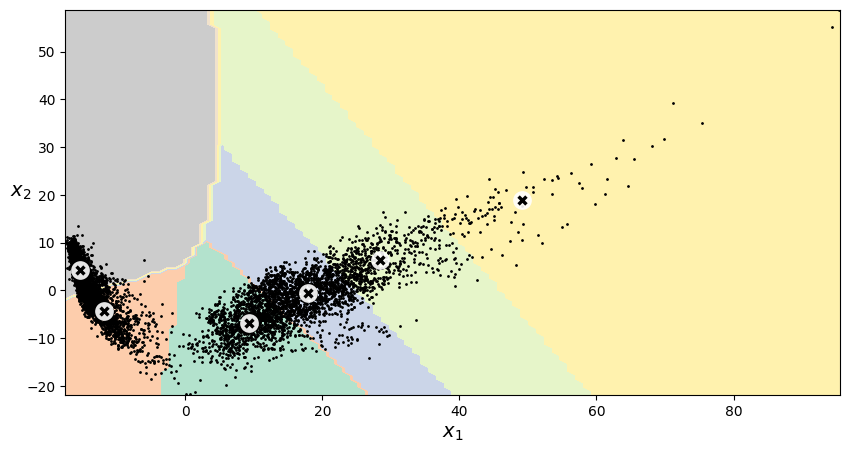

In [ ]:
# ten wykres pokazuje że dzięki redukcji wymiarów mamy lepsze rezultaty
# centroidy są lepiej wyśrodkowane
plt.figure(figsize=(10, 5))
plot_decision_boundaries(clf, X_pca)
plt.show()

In [ ]:
silhouette_scores = [silhouette_score(X, model.labels_)
                     for model in kmeans_per_k[1:]]

In [ ]:
silhouette_scores

[np.float64(0.39650058094388707),
 np.float64(0.3274077920801446),
 np.float64(0.1607647994853622),
 np.float64(0.13057288294597452),
 np.float64(0.10880026355767618),
 np.float64(0.08261591321211258),
 np.float64(0.10794345912502407),
 np.float64(0.08502298792230273)]

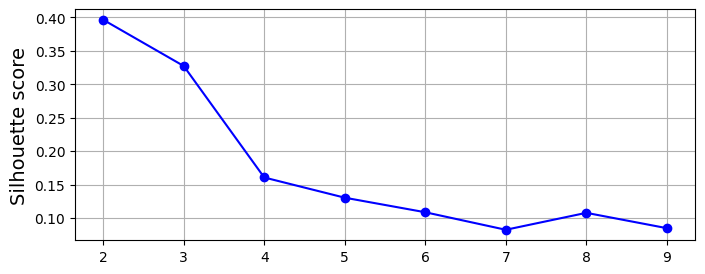

In [ ]:
plt.figure(figsize=(8, 3))
plt.plot(range(2, 10), silhouette_scores, "bo-")
plt.ylabel("Silhouette score", fontsize=14)
plt.grid()
plt.show()

In [ ]:
dbscan = DBSCAN(eps=0.2, min_samples=5)
dbscan.fit(X_pca)

DBSCAN(eps=0.2)

In [ ]:
# funkcja do rysowania modelu DBSCAN
def plot_dbscan(dbscan, X, size):
    core_mask = np.zeros_like(dbscan.labels_, dtype=bool)
    core_mask[dbscan.core_sample_indices_] = True
    anomalies_mask = dbscan.labels_ == -1
    non_core_mask = ~(core_mask | anomalies_mask)

    cores = dbscan.components_
    anomalies = X[anomalies_mask]
    non_cores = X[non_core_mask]

    plt.scatter(cores[:, 0], cores[:, 1],
                c=dbscan.labels_[core_mask], marker='o', s=size, cmap="Paired")
    plt.scatter(cores[:, 0], cores[:, 1], marker='*', s=20, c=dbscan.labels_[core_mask])
    plt.scatter(anomalies[:, 0], anomalies[:, 1],
                c="r", marker="x", s=100)
    plt.scatter(non_cores[:, 0], non_cores[:, 1], c=dbscan.labels_[non_core_mask], marker=".")
    plt.title("eps={:.2f}, min_samples={}".format(dbscan.eps, dbscan.min_samples), fontsize=14)

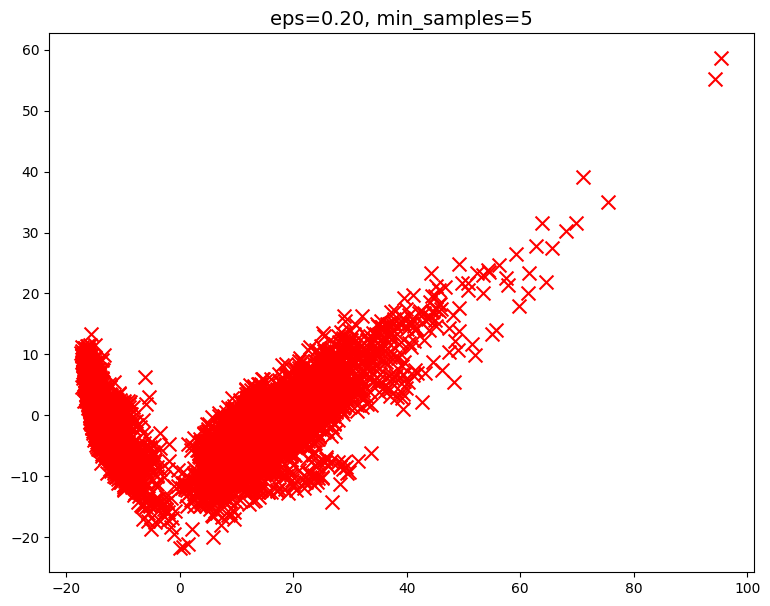

In [ ]:
# kolejny wykres który pokazuje skuteczność redukcji wymiarów - dzięki temu mamy mniej anomalii
plt.figure(figsize=(20, 7))

plt.subplot(121)
plot_dbscan(dbscan, X_pca, size=100)

plt.show()

In [ ]:
# kolejny model do klasteryzacji
gm = GaussianMixture(n_components=3, n_init=5, random_state=42)
#gm.fit(X)
# tutaj ten sam problem co wcześniej, abym mógł narysować wykres muszę pobierać tylko 2 kolumny
gm.fit(X_pca[:, :2])

GaussianMixture(n_components=3, n_init=5, random_state=42)

In [ ]:
gm_predict = gm.predict(Y_test_pca[:, :2])
print("score dla danych testowych ", gm_predict)

score dla danych testowych  [0 0 0 ... 2 2 2]


In [ ]:
# metoda zaporzyczona z przykładów sklearn oraz lekko zmodyfikowana zmodyfikowana
def plot_gaussian_mixture(clf, X, resolution=1000):
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(np.linspace(mins[0], maxs[0], resolution),
                         np.linspace(mins[1], maxs[1], resolution))
    Z = -clf.score_samples(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z,
                 norm=LogNorm(vmin=1.0, vmax=30.0),
                 levels=np.logspace(0, 2, 12))
    plt.contour(xx, yy, Z,
                norm=LogNorm(vmin=1.0, vmax=30.0),
                levels=np.logspace(0, 2, 12),
                linewidths=1, colors='k')

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contour(xx, yy, Z, linewidths=3, colors='b')

    plt.plot(X[:, 0], X[:, 1], 'k.', markersize=2)

    plt.xlabel("$x_1$", fontsize=14)
    plt.tick_params(labelleft=False)

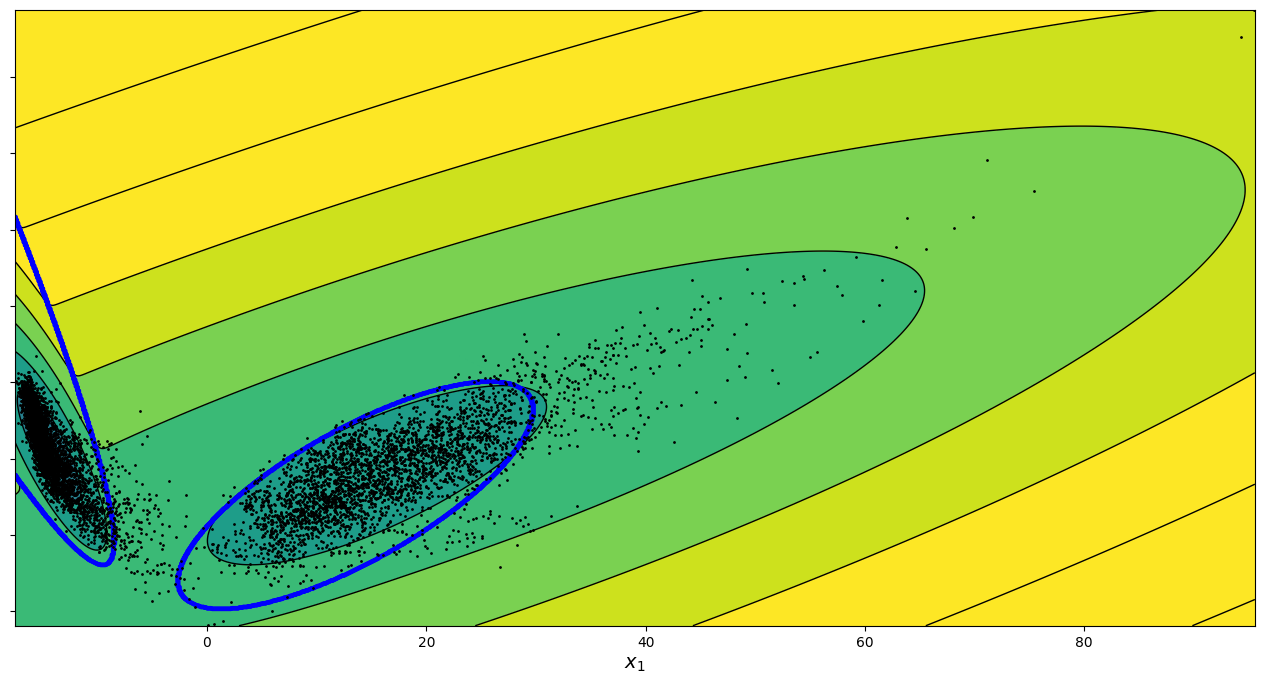

In [ ]:
plt.figure(figsize=(16, 8))

plot_gaussian_mixture(gm, X_pca)
plt.show()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=42
)

In [ ]:
# pierwszy klasyfikator z rodziny Supervised Learning
forest_clf = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42)
# trenujemy model
forest_clf.fit(X_train, y_train)
# w przypadków klasyfikatorów z rodziny Supervised Learning mamy gorsze rezultaty z powodu redukcji wymiarów
print("score dla danych treningowych ", forest_clf.score(X_train, y_train))

print("score dla danych testowych ", forest_clf.score(X_test, y_test))

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


score dla danych treningowych  0.8842033667743581
score dla danych testowych  0.8518014955812373


In [ ]:
# drugi klasyfikator z rodziny Supervised Learning
tree_clf = DecisionTreeClassifier(max_depth=10, random_state=2)

tree_clf.fit(X_train, y_train)
# w przypadku tego modelu również mamy trochę gorsze wyniki
print("score dla danych treningowych ", tree_clf.score(X_train, y_train))

print("score dla danych testowych ", tree_clf.score(X_test, y_test))

score dla danych treningowych  0.9693929603808876
score dla danych testowych  0.8021753908905507


In [ ]:
# stworzenie KFold obiektu z 5 foldami i tasowaniem danych
kf = KFold(n_splits=5, shuffle=True, random_state=1)

models = []
scores = []

# iteracja przez poszczególne foldy
for fold_nr, (train_idx, test_idx) in enumerate(kf.split(X_pca)):
    # musiałem zmodyfikować ten kod bo dostawałem jakiś błąd odnośnie zakresu w tych listach
    # zakresy się różniły między danymi treningowymi a testowymi
    X_train = X_pca[0:len(train_idx)]
    X_test = X_pca[0:len(test_idx)]
    y_train = y[0:len(train_idx)]
    y_test = y[0:len(test_idx)]

    # skalowanie danych wewnątrz poszczeŋólnych iteracji
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # stworzenie klasyfikatora dla poszczególnej iteracji
    # wytrenowanie klasyfikatora na danych treningowych
    clf = SGDClassifier(random_state=1).fit(X_train, y_train)

    # dodawanie klasyfikatora do tablicy klasyfikatorów
    models.append(clf)
    # dodawanie wyniku dla danych testowych do tablicy
    scores.append(clf.score(X_test, y_test))
# wyniki z poszczególnych foldów są bardzo dobre
print("wyniki poszczególnych foldów: ", scores)
print("sredni wynik wszystkich foldów: ", np.array(scores).mean())

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for exam

wyniki poszczególnych foldów:  [0.9830047586675731, 0.9830047586675731, 0.9809523809523809, 0.9809523809523809, 0.9809523809523809]
sredni wynik wszystkich foldów:  0.9817733320384578


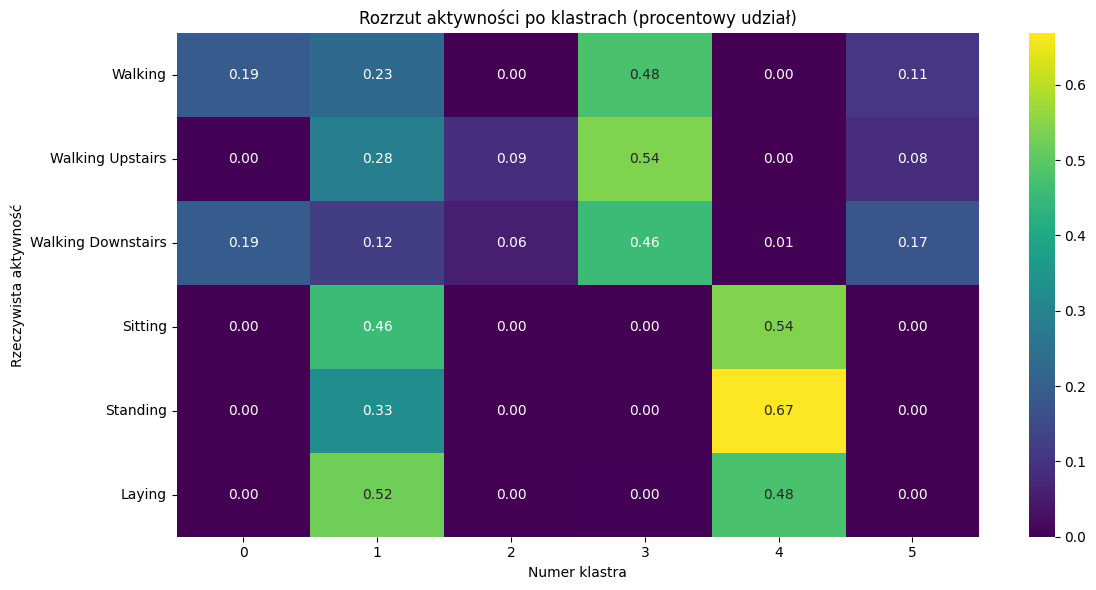

In [ ]:
kmeans = KMeans(n_clusters=6, random_state=42)
labels_pred = kmeans.fit_predict(X_train)

# Tabela krzyżowa: rzeczywiste etykiety vs przypisane klastry
activity_cluster_dist = pd.crosstab(y_train.iloc[:, 0], labels_pred, normalize='index')

# Mapowanie etykiet
activity_labels = {
    1: "Walking",
    2: "Walking Upstairs",
    3: "Walking Downstairs",
    4: "Sitting",
    5: "Standing",
    6: "Laying"
}
activity_cluster_dist.index = activity_cluster_dist.index.map(activity_labels)

# Sortowanie
activity_cluster_dist = activity_cluster_dist.loc[
    ["Walking", "Walking Upstairs", "Walking Downstairs", "Sitting", "Standing", "Laying"]
]

# Heatmapa
plt.figure(figsize=(12, 6))
sns.heatmap(activity_cluster_dist, annot=True, cmap="viridis", fmt=".2f")
plt.title("Rozrzut aktywności po klastrach (procentowy udział)")
plt.xlabel("Numer klastra")
plt.ylabel("Rzeczywista aktywność")
plt.tight_layout()
plt.show()

Krótkie podsumowanie: generalnie redukcja wymiarów pomaga różnym metodą klasteringu - wszystkie modele uzyskały lepsze rezultaty.
W przypadku klasyfikatorów Supervised Learning efekt jest trochę gorszy, chociaż wciąż chyba satysfakcjonujący.